# Analisis Komparatif Strategi Algoritma Trading Berbasis Indikator Teknikal
## EMA, RSI, dan MACD pada Indeks Utama AS (S&P 500, NASDAQ 100, Dow Jones)

**Notebook Riset Kuantitatif — Tugas Akhir (Skripsi)**

---

Notebook ini mengimplementasikan sistem trading deterministik berbasis **Dynamic Trailing Stop Long-Only**
(menangkap pergerakan tren besar menggunakan trailing stop dinamis 1.5% dan Extreme TP 5%)
pada data 1-hour (H1) tiga indeks utama AS.

In [1]:
# =============================================================================
# SEL 1: ENVIRONMENT SETUP & INSTALASI LIBRARY
# =============================================================================
# Instalasi dependensi utama yang dibutuhkan untuk analisis kuantitatif.
# - pandas      : Manipulasi data tabular dan time-series.
# - numpy       : Operasi numerik dan array.
# - pyarrow     : Backend I/O untuk format Parquet.
# - matplotlib  : Visualisasi grafik ilmiah.
# - seaborn     : Ekstensi estetika visualisasi matplotlib.

!pip install pandas numpy pyarrow matplotlib seaborn
!pip install yfinance



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# =============================================================================
# SEL 2: IMPORT LIBRARY & FUNGSI PEMROSESAN DATA UNIVERSAL
# =============================================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Konfigurasi tampilan dan gaya visualisasi
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', 20)


def proses_data_instrumen(filepath):
    """
    Fungsi modular untuk memuat dan memproses data instrumen keuangan.
    Mendukung format Parquet dan CSV tab-separated secara otomatis.
    
    Tahapan pemrosesan:
    1. Deteksi format file (Parquet / CSV tab-separated).
    2. Standarisasi nama kolom (lowercase, strip whitespace).
    3. Konversi kolom waktu ke DatetimeIndex.
    4. Pengurutan kronologis menaik.
    5. Kalkulasi indikator teknikal: EMA (50, 100, 200), MACD (12, 26, 9), RSI (14).
    6. Pembersihan baris NaN akibat periode lookback indikator.
    
    Parameters
    ----------
    filepath : str
        Path ke file data (Parquet atau CSV).
    
    Returns
    -------
    pd.DataFrame
        DataFrame terproses dengan indikator teknikal dan DatetimeIndex.
    """
    # --- Tahap 1: Deteksi format dan muat data ---
    if filepath.endswith('.parquet'):
        df = pd.read_parquet(filepath)
    else:
        df = pd.read_csv(filepath, sep='\t')
    
    # --- Tahap 2: Standarisasi nama kolom ---
    df.columns = df.columns.str.strip().str.lower()
    
    # --- Tahap 3: Konversi kolom waktu ke DatetimeIndex ---
    if 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
    elif 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))
        df.set_index('datetime', inplace=True)
        df.drop(columns=['date', 'time'], inplace=True, errors='ignore')
    else:
        raise ValueError(f"Kolom datetime tidak ditemukan pada file: {filepath}")
    
    # Hapus kolom non-OHLC yang tidak dibutuhkan
    kolom_pertahankan = ['open', 'high', 'low', 'close', 'volume']
    kolom_tersedia = [k for k in kolom_pertahankan if k in df.columns]
    df = df[kolom_tersedia]
    
    # --- Tahap 4: Pengurutan kronologis menaik ---
    df.sort_index(inplace=True)
    
    # --- Tahap 5: Kalkulasi Indikator Teknikal ---
    
    # 5a. EMA (Exponential Moving Average) — span 50, 100, 200
    df['ema_50'] = df['close'].ewm(span=50, adjust=False).mean()
    df['ema_100'] = df['close'].ewm(span=100, adjust=False).mean()
    df['ema_200'] = df['close'].ewm(span=200, adjust=False).mean()
    
    # 5b. MACD (Moving Average Convergence Divergence)
    #     Fast EMA (span=12), Slow EMA (span=26), Signal Line (span=9)
    ema_fast = df['close'].ewm(span=12, adjust=False).mean()
    ema_slow = df['close'].ewm(span=26, adjust=False).mean()
    df['macd_line'] = ema_fast - ema_slow
    df['macd_signal'] = df['macd_line'].ewm(span=9, adjust=False).mean()
    
    # 5c. RSI (Relative Strength Index) — Wilder's Smoothing, periode 14
    #     Menggunakan alpha = 1/14 sesuai metode standar Wilder.
    delta = df['close'].diff()
    gain = delta.clip(lower=0)
    loss = (-delta).clip(lower=0)
    
    avg_gain = gain.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/14, min_periods=14, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    df['rsi'] = 100 - (100 / (1 + rs))
    
    # --- Tahap 6: Pembersihan baris NaN ---
    df.dropna(inplace=True)
    
    return df


print("[OK] Fungsi proses_data_instrumen() berhasil didefinisikan.")
print("     Mendukung: Parquet, CSV (tab-separated)")
print("     Indikator: EMA(50,100,200), MACD(12,26,9), RSI(14)")

[OK] Fungsi proses_data_instrumen() berhasil didefinisikan.
     Mendukung: Parquet, CSV (tab-separated)
     Indikator: EMA(50,100,200), MACD(12,26,9), RSI(14)


In [3]:
# =============================================================================
# SEL 3: PEMUATAN DATA PER INSTRUMEN INDEKS
# =============================================================================
# Memproses tiga instrumen utama AS menggunakan fungsi universal.
# Path menggunakan forward-slash agar kompatibel lintas OS (Windows/Linux).

# --- S&P 500 (SPY ETF) — Format Parquet ---
print("Memproses S&P 500 (SPY)...")
df_spy = proses_data_instrumen('TA/spy_US500_H1.parquet')
print(f"  Baris: {len(df_spy):,} | Periode: {df_spy.index.min()} s/d {df_spy.index.max()}")

# --- NASDAQ 100 — Format CSV Tab-Separated ---
print("\nMemproses NASDAQ 100...")
df_ndx = proses_data_instrumen('TA/Nasdaq100_1h_data.csv')
print(f"  Baris: {len(df_ndx):,} | Periode: {df_ndx.index.min()} s/d {df_ndx.index.max()}")

# --- Dow Jones Industrial Average — Format CSV Tab-Separated ---
print("\nMemproses Dow Jones (DJI)...")
df_dji = proses_data_instrumen('TA/Dow_Jones_1h_data.csv')
print(f"  Baris: {len(df_dji):,} | Periode: {df_dji.index.min()} s/d {df_dji.index.max()}")

print("\n" + "="*60)
print("[OK] Seluruh instrumen berhasil dimuat dan diproses.")

Memproses S&P 500 (SPY)...
  Baris: 50,158 | Periode: 2018-02-20 10:00:00 s/d 2026-08-19 11:00:00

Memproses NASDAQ 100...
  Baris: 51,875 | Periode: 2016-11-15 20:00:00 s/d 2025-10-01 07:00:00

Memproses Dow Jones (DJI)...
  Baris: 49,311 | Periode: 2016-10-27 15:00:00 s/d 2025-07-15 20:00:00

[OK] Seluruh instrumen berhasil dimuat dan diproses.


In [4]:
# =============================================================================
# SEL 4: PENYELARASAN TIMELINE (STRICT TIMELINE INTERSECTION)
# =============================================================================
# Ketiga instrumen memiliki jam perdagangan dan anomali bar libur yang
# sedikit berbeda. Analisis komparatif HANYA valid pada irisan timestamp
# yang identik di ketiga instrumen.
#
# Target: 41.653 baris data seragam, periode Februari 2018 — Juli 2025.

# Hitung irisan timestamp tiga arah
common_timeline = (
    df_spy.index
    .intersection(df_ndx.index)
    .intersection(df_dji.index)
)
common_timeline = common_timeline.sort_values()

# Reindex setiap instrumen ke irisan bersama
df_spy_final = df_spy.loc[common_timeline].copy()
df_ndx_final = df_ndx.loc[common_timeline].copy()
df_dji_final = df_dji.loc[common_timeline].copy()

# --- Validasi Hasil Penyelarasan ---
print("=" * 60)
print("VALIDASI PENYELARASAN TIMELINE")
print("=" * 60)
print(f"Jumlah bar irisan bersama  : {len(common_timeline):,}")
print(f"Tanggal awal               : {common_timeline.min()}")
print(f"Tanggal akhir              : {common_timeline.max()}")
print(f"\nBaris SPY final            : {len(df_spy_final):,}")
print(f"Baris NASDAQ final         : {len(df_ndx_final):,}")
print(f"Baris DJI final            : {len(df_dji_final):,}")

# Verifikasi kesamaan jumlah baris
assert len(df_spy_final) == len(df_ndx_final) == len(df_dji_final), \
    "ERROR: Jumlah baris ketiga instrumen tidak seragam setelah alignment!"

print(f"\n[OK] Ketiga instrumen selaras sempurna: {len(df_spy_final):,} baris.")
print(f"     Rentang: {common_timeline.min()} — {common_timeline.max()}")

VALIDASI PENYELARASAN TIMELINE
Jumlah bar irisan bersama  : 41,641
Tanggal awal               : 2018-02-20 10:00:00
Tanggal akhir              : 2025-07-15 20:00:00

Baris SPY final            : 41,641
Baris NASDAQ final         : 41,641
Baris DJI final            : 41,641

[OK] Ketiga instrumen selaras sempurna: 41,641 baris.
     Rentang: 2018-02-20 10:00:00 — 2025-07-15 20:00:00


In [5]:
# =============================================================================
# SEL 5: MESIN STRATEGI KUANTITATIF (QUANTITATIVE STRATEGY ENGINE)
# =============================================================================
# Implementasi sistem trading deterministik DYNAMIC TRAILING STOP LONG-ONLY
# berbasis filosofi "Let Profits Run & Protect Capital":
#   - Entry menggunakan konfirmasi akurasi tinggi (RSI cross di atas 50).
#   - Keluar secara presisi menggunakan Trailing Stop Dinamis (1.5% dari High).
#   - Extreme Take Profit (5%) sebagai pengaman spike/anomali pergerakan.
#
# Fitur utama:
#   - Sinyal HANYA Long (+1) dan Flat (0).
#   - Iterasi State-Machine untuk melacak Trailing Stop harga riil.
#   - Menghitung exact return exit berdasarkan harga trigger (bukan close bar),
#     sehingga sangat presisi untuk H1 timeframe.

import numpy as np
import pandas as pd

def simulasi_strategi(df, nama_instrumen, biaya=0.0002):
    """
    Menjalankan simulasi strategi trading Dynamic Trailing Stop Long-Only.
    """
    data = df.copy()
    
    # === KOMPONEN SINYAL ENTRY ===
    # --- Filter Tren Utama ---
    tren_naik = (data['ema_50'] > data['ema_100']) & (data['ema_100'] > data['ema_200'])
    
    # --- Filter Momentum MACD ---
    macd_bullish = data['macd_line'] > data['macd_signal']
    
    # --- Sinyal Pemicu (RSI Cross Above 50) ---
    rsi_cross_above_50 = (data['rsi'].shift(1) <= 50) & (data['rsi'] > 50)
    
    # === KONDISI ENTRY (Long Only) ===
    sinyal_long  = tren_naik & macd_bullish & rsi_cross_above_50
    sl_signal = sinyal_long.values
    
    # Deteksi kolom high/low untuk presisi TS intraday
    has_hl = 'high' in data.columns and 'low' in data.columns
    if has_hl:
        high_vals = data['high'].values
        low_vals = data['low'].values
    else:
        high_vals = data['close'].values
        low_vals = data['close'].values
    
    close_vals = data['close'].values
    
    # === ARRAY PELACAK STATE & RETURN ===
    p = np.zeros(len(data))
    ret_strat = np.zeros(len(data))
    trade_exec = np.zeros(len(data))
    
    # === PARAMETER MANAJEMEN RISIKO DINAMIS ===
    trailing_dist = 0.015  # Jarak TS 1.5%
    extreme_tp = 0.05      # Extreme TP 5%
    
    curr = 0.0
    highest_price = 0.0
    sl_price = 0.0
    tp_price = 0.0
    
    for i in range(1, len(data)):
        if curr == 0.0:
            if sl_signal[i-1]:  # Entry tereksekusi pada OPEN/awal bar i akibat sinyal di i-1
                curr = 1.0
                entry_price = close_vals[i-1] # Harga masuk adalah close bar lalu
                highest_price = entry_price
                sl_price = entry_price * (1 - trailing_dist)
                tp_price = entry_price * (1 + extreme_tp)
                
                p[i] = 1.0
                trade_exec[i] = 1.0 # Biaya buka
                
                # Check apakah di bar yang sama (bar ke-i) harga memukul stop atau TP
                hit_tp = high_vals[i] >= tp_price
                hit_sl = low_vals[i] <= sl_price
                
                if hit_tp or hit_sl:
                    curr = 0.0
                    p[i] = 0.0
                    trade_exec[i] += 1.0 # Biaya tutup langsung
                    
                    # Conservatively assume SL hits first if both are hit
                    exit_price = sl_price if hit_sl else tp_price
                    ret_strat[i] = (exit_price / close_vals[i-1]) - 1.0
                else:
                    ret_strat[i] = (close_vals[i] / close_vals[i-1]) - 1.0
                    # Update trailing
                    if high_vals[i] > highest_price:
                        highest_price = high_vals[i]
                        sl_price = max(sl_price, highest_price * (1 - trailing_dist))
                        
        elif curr == 1.0:
            hit_tp = high_vals[i] >= tp_price
            hit_sl = low_vals[i] <= sl_price
            
            if hit_tp or hit_sl:
                curr = 0.0
                p[i] = 0.0
                trade_exec[i] = 1.0 # Biaya tutup
                
                # Conservatively assume SL hits first if both are hit
                exit_price = sl_price if hit_sl else tp_price
                ret_strat[i] = (exit_price / close_vals[i-1]) - 1.0
            else:
                p[i] = 1.0
                ret_strat[i] = (close_vals[i] / close_vals[i-1]) - 1.0
                
                # Update trailing setelah memastikan selamat bar ini
                if high_vals[i] > highest_price:
                    highest_price = high_vals[i]
                    sl_price = max(sl_price, highest_price * (1 - trailing_dist))
                    
    data['posisi'] = p
    
    # === KALKULASI RETURN FINAL ===
    return_pasar = data['close'].pct_change().fillna(0)
    
    # Final strategi return per bar: return harian - biaya komisi trade di bar tersebut
    return_strategi = pd.Series(ret_strat, index=data.index) - (pd.Series(trade_exec, index=data.index) * biaya)
    return_strategi = return_strategi.fillna(0)
    
    # === EQUITY CURVE ===
    return_kumulatif = (1 + return_strategi).cumprod()
    return_bnh = (1 + return_pasar).cumprod()
    
    # === DRAWDOWN ===
    peak_kumulatif = return_kumulatif.cummax()
    drawdown = (return_kumulatif - peak_kumulatif) / peak_kumulatif
    
    # === LOG TRANSAKSI ===
    perubahan = pd.Series(trade_exec, index=data.index)
    mask_transaksi = perubahan != 0
    
    log = data.loc[mask_transaksi, ['close', 'rsi', 'macd_line', 'macd_signal', 'posisi']].copy()
    perubahan_log = perubahan[mask_transaksi]
    log['aksi'] = np.where(perubahan_log > 1, 'BUY & SELL', np.where((perubahan_log == 1) & (log['posisi'] == 1), 'LONG ENTRY', 'EXIT (TS/TP)'))
    
    print(f"  [{nama_instrumen}] Strategi selesai — "
          f"Total sinyal/transaksi: {mask_transaksi.sum()}, "
          f"Return akhir: {return_kumulatif.iloc[-1]:.4f}x")
    
    return {
        'nama': nama_instrumen,
        'return_strategi': return_strategi,
        'return_kumulatif': return_kumulatif,
        'return_bnh': return_bnh,
        'drawdown': drawdown,
        'log_transaksi': log,
        'posisi': data['posisi']
    }

# --- Eksekusi Strategi ---
print("Menjalankan simulasi strategi kuantitatif (Dynamic Trailing Stop Long-Only)...\n")

hasil_spy = simulasi_strategi(df_spy_final, 'S&P 500 (SPY)')
hasil_ndx = simulasi_strategi(df_ndx_final, 'NASDAQ 100')
hasil_dji = simulasi_strategi(df_dji_final, 'Dow Jones (DJI)')

daftar_hasil = [hasil_spy, hasil_ndx, hasil_dji]

print("\n" + "="*60)
print("[OK] Simulasi strategi selesai.")

Menjalankan simulasi strategi kuantitatif (Dynamic Trailing Stop Long-Only)...

  [S&P 500 (SPY)] Strategi selesai — Total sinyal/transaksi: 261, Return akhir: 1.2648x
  [NASDAQ 100] Strategi selesai — Total sinyal/transaksi: 335, Return akhir: 1.1466x
  [Dow Jones (DJI)] Strategi selesai — Total sinyal/transaksi: 230, Return akhir: 1.1974x

[OK] Simulasi strategi selesai.


In [6]:
# =============================================================================
# SEL 6: TABEL EVALUASI KINERJA (PERFORMANCE METRICS TABLE)
# =============================================================================
# Menghitung metrik finansial standar riset akademik untuk evaluasi
# komparatif ketiga instrumen.
#
# Asumsi:
#   - Data H1 (1-jam), 7 bar per hari perdagangan × 252 hari = 1.764 bar/tahun.
#   - Risk-free rate = 0%.
#   - Biaya transaksi sudah terinternalisasi dalam return strategi.

BARS_PER_TAHUN = 252 * 7  # 1.764 bar H1 per tahun


def hitung_metrik(hasil, bars_per_tahun=BARS_PER_TAHUN):
    """
    Menghitung metrik kinerja kuantitatif komprehensif.
    
    Metrik yang dihitung:
    1. Total Cumulative Return (%)
    2. CAGR (%)
    3. Annualized Volatility (%)
    4. Sharpe Ratio (Risk-Free Rate = 0%)
    5. Sortino Ratio (Downside deviation only)
    6. Maximum Drawdown (%)
    7. Win Rate (%) — per siklus trade selesai (entry-to-exit)
    8. Profit Factor — Gross Profit / Gross Loss
    9. Total Trades — Jumlah siklus transaksi selesai
    
    Parameters
    ----------
    hasil : dict
        Output dari fungsi simulasi_strategi().
    bars_per_tahun : int
        Jumlah bar per tahun untuk annualisasi (default: 1.764).
    
    Returns
    -------
    dict
        Dictionary metrik kinerja.
    """
    ret = hasil['return_strategi']
    cum = hasil['return_kumulatif']
    dd = hasil['drawdown']
    posisi = hasil['posisi']
    
    # 1. Total Cumulative Return
    total_return = cum.iloc[-1] - 1
    
    # 2. CAGR (Compound Annual Growth Rate)
    total_bars = len(ret)
    total_tahun = total_bars / bars_per_tahun
    cagr = (cum.iloc[-1] ** (1 / total_tahun)) - 1 if total_tahun > 0 else 0
    
    # 3. Annualized Volatility
    vol_tahunan = ret.std() * np.sqrt(bars_per_tahun)
    
    # 4. Annualized Sharpe Ratio (risk-free rate = 0%)
    sharpe = (ret.mean() / ret.std()) * np.sqrt(bars_per_tahun) if ret.std() > 0 else 0
    
    # 5. Annualized Sortino Ratio (hanya downside deviation)
    downside_ret = ret[ret < 0]
    downside_std = downside_ret.std() if len(downside_ret) > 0 else 0
    sortino = (ret.mean() / downside_std) * np.sqrt(bars_per_tahun) if downside_std > 0 else 0
    
    # 6. Maximum Drawdown
    max_drawdown = dd.min()
    
    # 7–9. Metrik berbasis siklus transaksi selesai (trade-level)
    # Identifikasi setiap siklus transaksi entry→exit sebagai satu trade selesai.
    # Satu trade dimulai saat posisi berubah dari 0 ke ±1, dan berakhir saat
    # posisi kembali ke 0.
    perubahan = posisi.diff().fillna(posisi)
    idx_perubahan = perubahan[perubahan != 0].index
    
    trade_returns = []
    i = 0
    while i < len(idx_perubahan):
        pos_val = posisi.loc[idx_perubahan[i]]
        if pos_val != 0:
            # Ini adalah entry — cari exit berikutnya (posisi = 0)
            start = idx_perubahan[i]
            exit_found = False
            for j in range(i + 1, len(idx_perubahan)):
                if posisi.loc[idx_perubahan[j]] == 0:
                    end = idx_perubahan[j]
                    # Return kumulatif per siklus trade
                    trade_ret = ret.loc[start:end]
                    trade_cum = (1 + trade_ret).prod() - 1
                    trade_returns.append(trade_cum)
                    i = j + 1
                    exit_found = True
                    break
            if not exit_found:
                # Trade masih terbuka (belum ada exit) — hitung sampai akhir data
                trade_ret = ret.loc[start:]
                trade_cum = (1 + trade_ret).prod() - 1
                trade_returns.append(trade_cum)
                break
        else:
            i += 1
    
    trade_returns = np.array(trade_returns)
    total_trades = len(trade_returns)
    
    # Win Rate
    winning = trade_returns[trade_returns > 0]
    win_rate = len(winning) / total_trades * 100 if total_trades > 0 else 0
    
    # Profit Factor (Gross Profit / Gross Loss)
    gross_profit = winning.sum() if len(winning) > 0 else 0
    losing = trade_returns[trade_returns < 0]
    gross_loss = abs(losing.sum()) if len(losing) > 0 else 1e-10  # Hindari div-by-zero
    profit_factor = gross_profit / gross_loss
    
    return {
        'Instrumen': hasil['nama'],
        'Total Cumulative Return (%)': total_return * 100,
        'CAGR (%)': cagr * 100,
        'Annualized Volatility (%)': vol_tahunan * 100,
        'Sharpe Ratio': sharpe,
        'Sortino Ratio': sortino,
        'Max Drawdown (%)': max_drawdown * 100,
        'Win Rate (%)': win_rate,
        'Profit Factor': profit_factor,
        'Total Trades': total_trades
    }


# --- Kompilasi Tabel Metrik ---
metrik_list = [hitung_metrik(h) for h in daftar_hasil]
df_metrik = pd.DataFrame(metrik_list).set_index('Instrumen')

print("=" * 80)
print("RINGKASAN KINERJA KOMPARATIF — STRATEGI DYNAMIC TRAILING STOP LONG-ONLY")
print("Periode Analisis:", common_timeline.min().strftime('%Y-%m-%d'),
      "s/d", common_timeline.max().strftime('%Y-%m-%d'))
print(f"Jumlah Bar: {len(common_timeline):,} | Biaya: 0.02% per eksekusi")
print("=" * 80)
print()
print(df_metrik.to_string())
print()

RINGKASAN KINERJA KOMPARATIF — STRATEGI DYNAMIC TRAILING STOP LONG-ONLY
Periode Analisis: 2018-02-20 s/d 2025-07-15
Jumlah Bar: 41,641 | Biaya: 0.02% per eksekusi

                 Total Cumulative Return (%)  CAGR (%)  Annualized Volatility (%)  Sharpe Ratio  Sortino Ratio  Max Drawdown (%)  Win Rate (%)  Profit Factor  Total Trades
Instrumen                                                                                                                                                                  
S&P 500 (SPY)                        26.4784    1.0001                     3.7077        0.2869         0.2042          -12.9681       39.6947         1.3713           131
NASDAQ 100                           14.6613    0.5812                     3.9106        0.1678         0.0990          -12.2927       36.3095         1.1687           168
Dow Jones (DJI)                      19.7368    0.7660                     3.4782        0.2368         0.1707           -9.6062       44.3478      

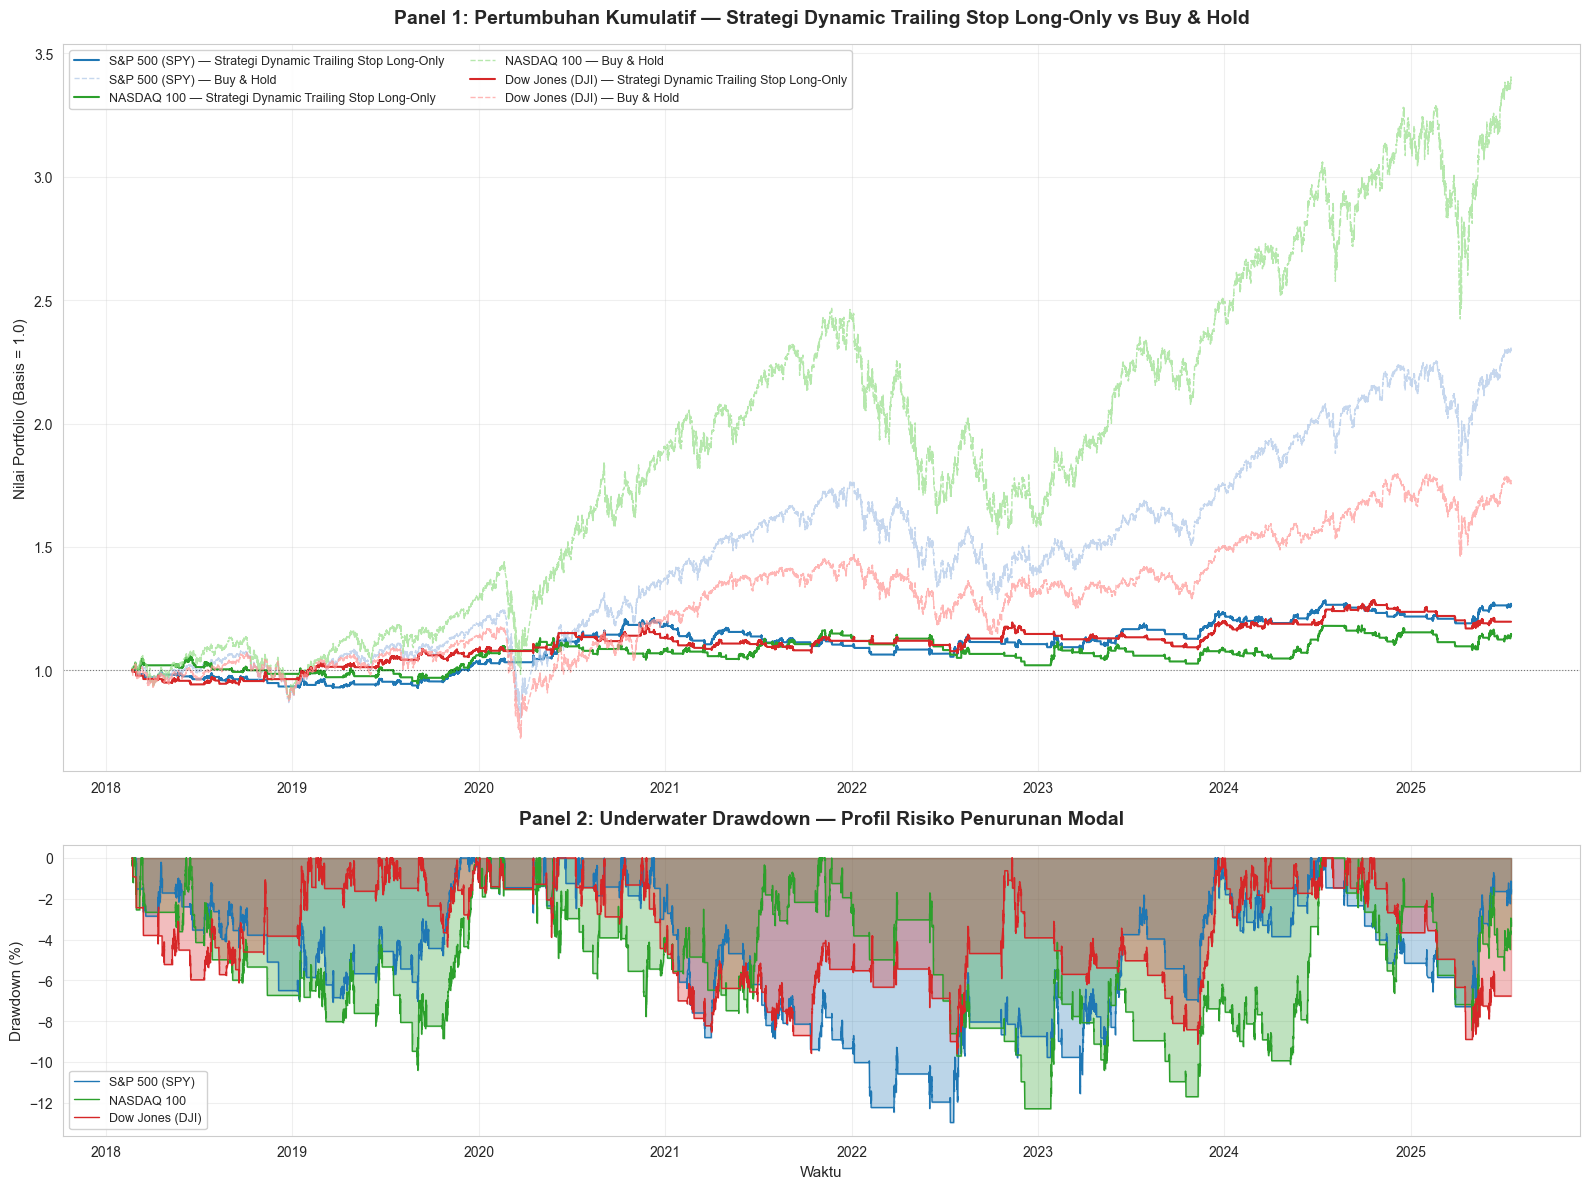

[OK] Grafik disimpan: equity_drawdown_chart.png

SAMPEL LOG TRANSAKSI (10 Entri Terakhir) — Untuk Lampiran Tesis

--- S&P 500 (SPY) ---
Total transaksi tercatat: 261
                        Close  RSI(14)  MACD Line  Posisi          Aksi
datetime                                                               
2025-05-06 11:00:00 5612.0500  34.4496    -7.0136  0.0000  EXIT (TS/TP)
2025-05-06 22:00:00 5602.9000  42.9567    -9.3532  1.0000    LONG ENTRY
2025-05-07 21:00:00 5624.3500  48.6768    -2.9322  0.0000  EXIT (TS/TP)
2025-05-08 04:00:00 5651.5000  59.3977     1.6949  1.0000    LONG ENTRY
2025-05-16 11:00:00 5927.1500  68.0068     9.5516  0.0000  EXIT (TS/TP)
2025-05-19 17:00:00 5931.9000  62.9988    -1.1932  1.0000    LONG ENTRY
2025-05-21 20:00:00 5871.5000  32.1813    -7.4830  0.0000  EXIT (TS/TP)
2025-05-30 23:00:00 5900.0000  50.5543    -7.0118  1.0000    LONG ENTRY
2025-06-13 03:00:00 5954.3500  28.1947    -1.8424  0.0000  EXIT (TS/TP)
2025-07-07 13:00:00 6258.1000  58.2327    

In [7]:
# =============================================================================
# SEL 7: VISUALISASI AKADEMIK & LOG AUDIT
# =============================================================================
# Panel 1: Grafik Pertumbuhan Kumulatif (Equity Curve) ketiga instrumen.
# Panel 2: Underwater Drawdown Chart (profil risiko penurunan modal).
# Sampel Log Transaksi: 10 transaksi terakhir per instrumen.

# --- Konfigurasi Warna Konsisten ---
WARNA = {
    'S&P 500 (SPY)': '#1f77b4',     # Biru
    'NASDAQ 100': '#2ca02c',         # Hijau
    'Dow Jones (DJI)': '#d62728'     # Merah
}
WARNA_BNH = {
    'S&P 500 (SPY)': '#aec7e8',     # Biru muda
    'NASDAQ 100': '#98df8a',         # Hijau muda
    'Dow Jones (DJI)': '#ff9896'     # Merah muda
}

# =====================================================================
# PANEL 1 & 2: EQUITY CURVE + DRAWDOWN (Height Ratio 2.5 : 1)
# =====================================================================
fig, axes = plt.subplots(2, 1, figsize=(16, 12),
                         gridspec_kw={'height_ratios': [2.5, 1]})

# --- Panel 1: Pertumbuhan Ekuitas Kumulatif ---
ax1 = axes[0]
for h in daftar_hasil:
    nama = h['nama']
    # Garis strategi (tebal, solid)
    ax1.plot(h['return_kumulatif'].index, h['return_kumulatif'].values,
             label=f"{nama} — Strategi Dynamic Trailing Stop Long-Only",
             color=WARNA[nama], linewidth=1.5)
    # Garis buy-and-hold (tipis, dashed)
    ax1.plot(h['return_bnh'].index, h['return_bnh'].values,
             label=f"{nama} — Buy & Hold",
             color=WARNA_BNH[nama], linewidth=1.0, linestyle='--', alpha=0.7)

ax1.axhline(y=1, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
ax1.set_title('Panel 1: Pertumbuhan Kumulatif — Strategi Dynamic Trailing Stop Long-Only vs Buy & Hold',
              fontsize=14, fontweight='bold', pad=15)
ax1.set_ylabel('Nilai Portfolio (Basis = 1.0)', fontsize=11)
ax1.legend(loc='upper left', fontsize=9, ncol=2, framealpha=0.9)
ax1.grid(True, alpha=0.3)

# --- Panel 2: Underwater Drawdown ---
ax2 = axes[1]
for h in daftar_hasil:
    nama = h['nama']
    ax2.fill_between(h['drawdown'].index, h['drawdown'].values * 100, 0,
                     alpha=0.3, color=WARNA[nama])
    ax2.plot(h['drawdown'].index, h['drawdown'].values * 100,
             label=nama, color=WARNA[nama], linewidth=1.0)

ax2.set_title('Panel 2: Underwater Drawdown — Profil Risiko Penurunan Modal',
              fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Drawdown (%)', fontsize=11)
ax2.set_xlabel('Waktu', fontsize=11)
ax2.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('equity_drawdown_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("[OK] Grafik disimpan: equity_drawdown_chart.png")


# =====================================================================
# SAMPEL LOG TRANSAKSI — 10 TRANSAKSI TERAKHIR PER INSTRUMEN
# =====================================================================
print("\n" + "=" * 80)
print("SAMPEL LOG TRANSAKSI (10 Entri Terakhir) — Untuk Lampiran Tesis")
print("=" * 80)

for h in daftar_hasil:
    log = h['log_transaksi']
    print(f"\n--- {h['nama']} ---")
    print(f"Total transaksi tercatat: {len(log)}")
    if len(log) > 0:
        tampilan = log.tail(10)[['close', 'rsi', 'macd_line', 'posisi', 'aksi']].copy()
        tampilan.columns = ['Close', 'RSI(14)', 'MACD Line', 'Posisi', 'Aksi']
        print(tampilan.to_string())
    else:
        print("  Tidak ada transaksi tercatat.")

print("\n" + "=" * 80)
print("[SELESAI] Seluruh analisis kuantitatif berhasil diselesaikan.")
print("=" * 80)

In [8]:
# ==========================================
# 1. FUNGSI EKSTRAKSI INDIKATOR (SESUAI PROPOSAL)
# ==========================================
def hitung_indikator(df):
    data = df.copy()
    
    # Triple EMA
    data['ema_50'] = data['Close'].ewm(span=50, adjust=False).mean()
    data['ema_100'] = data['Close'].ewm(span=100, adjust=False).mean()
    data['ema_200'] = data['Close'].ewm(span=200, adjust=False).mean()
    
    # MACD (12, 26, 9)
    ema_12 = data['Close'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Close'].ewm(span=26, adjust=False).mean()
    data['macd'] = ema_12 - ema_26
    data['macd_signal'] = data['macd'].ewm(span=9, adjust=False).mean()
    
    # RSI (14)
    delta = data['Close'].diff()
    gain = (delta.where(delta > 0, 0)).ewm(alpha=1/14, adjust=False).mean()
    loss = (-delta.where(delta < 0, 0)).ewm(alpha=1/14, adjust=False).mean()
    rs = gain / loss
    data['rsi'] = 100 - (100 / (1 + rs))
    
    return data.dropna()

# ==========================================
# 2. STATE-MACHINE ENGINE: TRAILING STOP LONG-ONLY
# ==========================================
def run_live_simulation(df, trailing_dist=0.015, extreme_tp=0.05, cost=0.0002):
    # Setup arrays
    posisi = 0
    entry_price = 0
    highest_price = 0
    sl_price = 0
    tp_price = 0
    
    posisi_arr = np.zeros(len(df))
    return_arr = np.zeros(len(df))
    trade_log = []
    
    # Ekstraksi array untuk kecepatan iterasi
    close_p = df['Close'].values
    high_p = df['High'].values
    low_p = df['Low'].values
    ema_50 = df['ema_50'].values
    ema_100 = df['ema_100'].values
    ema_200 = df['ema_200'].values
    macd = df['macd'].values
    signal = df['macd_signal'].values
    rsi = df['rsi'].values
    dates = df.index
    
    for i in range(1, len(df)):
        curr_close = close_p[i]
        curr_high = high_p[i]
        curr_low = low_p[i]
        
        # EVALUASI ENTRY (HANYA BISA MASUK JIKA POSISI 0)
        if posisi == 0:
            tren_bullish = (ema_50[i] > ema_100[i]) and (ema_100[i] > ema_200[i])
            macd_bullish = macd[i] > signal[i]
            rsi_cross_50 = (rsi[i-1] <= 50) and (rsi[i] > 50)
            
            if tren_bullish and macd_bullish and rsi_cross_50:
                posisi = 1
                entry_price = curr_close
                highest_price = entry_price
                sl_price = entry_price * (1 - trailing_dist)
                tp_price = entry_price * (1 + extreme_tp)
                
                return_arr[i] -= cost # Potong biaya entry
                trade_log.append({
                    'Waktu': dates[i].strftime('%Y-%m-%d %H:%M'), 
                    'Aksi': 'BUY', 
                    'Harga': round(entry_price, 2), 
                    'Profit (%)': '-'
                })
                
        # EVALUASI EXIT / TRAILING STOP (JIKA POSISI 1)
        elif posisi == 1:
            # 1. Update Trailing Stop (High Water Mark)
            if curr_high > highest_price:
                highest_price = curr_high
                new_sl = highest_price * (1 - trailing_dist)
                if new_sl > sl_price: # SL hanya boleh naik, tidak boleh turun
                    sl_price = new_sl
            
            # 2. Cek apakah harga menyentuh Trailing Stop (Cut Loss / Lock Profit)
            if curr_low <= sl_price:
                posisi = 0
                trade_ret = (sl_price - entry_price) / entry_price
                return_arr[i] += trade_ret - cost # Tambah profit/loss lalu potong biaya exit
                trade_log.append({
                    'Waktu': dates[i].strftime('%Y-%m-%d %H:%M'), 
                    'Aksi': 'SELL (Trailing)', 
                    'Harga': round(sl_price, 2), 
                    'Profit (%)': round(trade_ret * 100, 2)
                })
            
            # 3. Cek apakah harga menyentuh Extreme TP (Anomali Rally)
            elif curr_high >= tp_price:
                posisi = 0
                trade_ret = (tp_price - entry_price) / entry_price
                return_arr[i] += trade_ret - cost
                trade_log.append({
                    'Waktu': dates[i].strftime('%Y-%m-%d %H:%M'), 
                    'Aksi': 'SELL (Take Profit)', 
                    'Harga': round(tp_price, 2), 
                    'Profit (%)': round(trade_ret * 100, 2)
                })
                
        posisi_arr[i] = posisi
        
    df['Strategy_Return'] = return_arr
    df['Cum_Strategy'] = (1 + df['Strategy_Return']).cumprod()
    
    df_log = pd.DataFrame(trade_log)
    return df, df_log

# ==========================================
# 3. PROSES PENGAMBILAN DATA & SIMULASI
# ==========================================
tickers = {'S&P 500': 'SPY', 'NASDAQ 100': 'QQQ', 'Dow Jones': 'DIA'}

print("🚀 MEMULAI SIMULASI FORWARD TESTING (60 HARI TERAKHIR) 🚀\n")

for nama, ticker in tickers.items():
    print(f"=====================================================")
    print(f"📊 Menarik Data {nama} ({ticker}) - Timeframe 1H")
    
    # Tarik data 60 hari terakhir dari Yahoo Finance
    raw_data = yf.download(ticker, period="60d", interval="1h", progress=False)
    
    if raw_data.empty:
        print(f"⚠️ Gagal menarik data untuk {ticker}\n")
        continue
        
    # Pastikan single-index kolom (karena yfinance versi baru kadang multi-index)
    if isinstance(raw_data.columns, pd.MultiIndex):
        raw_data.columns = raw_data.columns.droplevel(1)
        
    # Hitung Indikator & Jalankan Simulasi
    df_indikator = hitung_indikator(raw_data)
    df_hasil, log_transaksi = run_live_simulation(df_indikator, trailing_dist=0.015, extreme_tp=0.05)
    
    total_return = (df_hasil['Cum_Strategy'].iloc[-1] - 1) * 100
    
    print(f"📈 Total Pertumbuhan Ekuitas: {total_return:.2f}%")
    print(f"📝 Rekap 5 Transaksi Terakhir:")
    
    if log_transaksi.empty:
        print("  - Tidak ada sinyal Entry yang valid dalam 2 bulan terakhir.")
    else:
        display(log_transaksi.tail()) # Gunakan print(log_transaksi.tail()) jika bukan di Jupyter Notebook
    print("\n")

🚀 MEMULAI SIMULASI FORWARD TESTING (60 HARI TERAKHIR) 🚀

📊 Menarik Data S&P 500 (SPY) - Timeframe 1H
📈 Total Pertumbuhan Ekuitas: -1.59%
📝 Rekap 5 Transaksi Terakhir:


,Waktu,Aksi,Harga,Profit (%)
0,2026-07-21 10:30,BUY,748.0000,-
1,2026-07-23 09:30,SELL (Trailing),738.7700,-1.2300
2,2026-08-25 15:30,BUY,765.8400,-
3,2026-09-01 09:30,SELL (Trailing),763.6700,-0.2800




📊 Menarik Data NASDAQ 100 (QQQ) - Timeframe 1H
📈 Total Pertumbuhan Ekuitas: 0.00%
📝 Rekap 5 Transaksi Terakhir:
  - Tidak ada sinyal Entry yang valid dalam 2 bulan terakhir.


📊 Menarik Data Dow Jones (DIA) - Timeframe 1H
📈 Total Pertumbuhan Ekuitas: -4.29%
📝 Rekap 5 Transaksi Terakhir:


,Waktu,Aksi,Harga,Profit (%)
5,2026-07-23 09:30,SELL (Trailing),516.5000,-1.1600
6,2026-08-13 09:30,BUY,539.6400,-
7,2026-08-20 09:30,SELL (Trailing),531.5500,-1.5000
8,2026-08-21 14:30,BUY,532.5900,-
9,2026-09-01 09:30,SELL (Trailing),529.6600,-0.5500
